Problem - 1: Perform a classification task with knn from scratch.
1. Load the Dataset:
• Read the dataset into a pandas DataFrame.
• Display the first few rows and perform exploratory data analysis (EDA) to understand the dataset
(e.g., check data types, missing values, summary statistics).
2. Handle Missing Data:
• Handle any missing values appropriately, either by dropping or imputing them based on the data.
3. Feature Engineering:
• Separate the feature matrix (X) and target variable (y).
• Perform a train - test split from scratch using a 70% − 30% ratio.
4. Implement KNN:

• Build the KNN algorithm from scratch (no libraries like sickit-learn for KNN).

• Compute distances using Euclidean distance.

• Write functions for:

– Predicting the class for a single query.

– Predicting classes for all test samples.

• Evaluate the performance using accuracy.

In [1]:
import pandas as pd
import numpy as np

In [6]:
# Load dataset
data = pd.read_csv("/content/drive/MyDrive/diabetes_.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
#1. Check basic dataset info
print("DATASET INFO:")
print(data.info())

# Check missing values
print("\nMISSING VALUES:")
print(data.isnull().sum())

# Summary statistics
print("\nSUMMARY STATISTICS:")
print(data.describe())

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

MISSING VALUES:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction

In [9]:
#2: Handle missing data (drop or fill depending on % missing)
missing_percent = data.isnull().sum() / len(data) * 100
missing_percent
# Fill or drop based on rule
for col in data.columns:
    if missing_percent[col] > 10:
        data[col].fillna(data[col].mean(), inplace=True)
    else:
        data.dropna(subset=[col], inplace=True)

print("Missing values after cleaning:")
print(data.isnull().sum())

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [11]:
#3. Create feature matrix X, target y, and split 70/30 from scratch
X = data.drop(columns=["Outcome"]).values
y = data["Outcome"].values
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)

    indices = np.arange(len(X))
    np.random.shuffle(indices)

    test_count = int(len(X) * test_size)

    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y)
X_train.shape, X_test.shape



((538, 8), (230, 8))

In [13]:
# 4.1 Compute Euclidean distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))


In [14]:
# 4.2 Predict class for a single query
def knn_predict_single(q, X_train, y_train, k=3):
    distances = [euclidean_distance(q, x) for x in X_train]
    sorted_idx = np.argsort(distances)
    nearest = sorted_idx[:k]
    return np.bincount(y_train[nearest]).argmax()





In [15]:
# 4.3 Predict classes for all test samples
def knn_predict(X_test, X_train, y_train, k=3):
    return np.array([knn_predict_single(x, X_train, y_train, k) for x in X_test])


In [21]:
# 4.4 Evaluate model accuracy
pred_original = knn_predict(X_test, X_train, y_train, k=3)
accuracy_original = compute_accuracy(y_test, pred_original)
accuracy_original


np.float64(67.3913043478261)

Problem - 2 - Experimentation:
1. Repeat the Classification Task:
• Scale the Feature matrix X.
• Use the scaled data for training and testing the kNN Classifier.
• Record the results.
2. Comparative Analysis: Compare the Results -

• Compare the accuracy and performance of the kNN model on the original dataset from problem 1 versus the scaled dataset.

• Discuss:
– How scaling impacted the KNN performance.
– The reason for any observed changes in accuracy.

In [22]:
# 1.1 Scale the feature matrix X
X_scaled = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
X_scaled[:5]


array([[0.35294118, 0.74371859, 0.59016393, 0.35353535, 0.        ,
        0.50074516, 0.23441503, 0.48333333],
       [0.05882353, 0.42713568, 0.54098361, 0.29292929, 0.        ,
        0.39642325, 0.11656704, 0.16666667],
       [0.47058824, 0.91959799, 0.52459016, 0.        , 0.        ,
        0.34724292, 0.25362938, 0.18333333],
       [0.05882353, 0.44723618, 0.54098361, 0.23232323, 0.11111111,
        0.41877794, 0.03800171, 0.        ],
       [0.        , 0.68844221, 0.32786885, 0.35353535, 0.19858156,
        0.64232489, 0.94363792, 0.2       ]])

In [23]:
# 1.2 Perform train-test split on scaled data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split_scratch(X_scaled, y)
X_train_s.shape, X_test_s.shape


((538, 8), (230, 8))

In [24]:
# 1.3 Run KNN on scaled data and compute accuracy
pred_scaled = knn_predict(X_test_s, X_train_s, y_train_s, k=3)
accuracy_scaled = compute_accuracy(y_test_s, pred_scaled)
accuracy_scaled


np.float64(69.1304347826087)

In [26]:
# 2. Compare accuracy before and after scaling
accuracy_original, accuracy_scaled


(np.float64(67.3913043478261), np.float64(69.1304347826087))

Problem - 3 - Experimentation with k:
1. Vary the number of neighbors - k:
• Run the KNN model on both the original and scaled datasets for a range of:

k= 1, 2, 3, . . . 15

• For each k, record:
– Accuracy.
– Time taken to make predictions.

2. Visualize the Results:
• Plot the following graphs:
– k vs. Accuracy for original and scaled datasets.
– k vs. Time Taken for original and scaled datasets.

3. Analyze and Discuss:
• Discuss how the choice of k affects the accuracy and computational cost.
• Identify the optimal k based on your analysis.

In [27]:
# 1.1 Accuracy for k = 1 to 15 (original data)
accuracy_original_list = []

for k in range(1, 16):
    pred_k = knn_predict(X_test, X_train, y_train, k)
    acc = compute_accuracy(y_test, pred_k)
    accuracy_original_list.append(acc)

accuracy_original_list


[np.float64(68.69565217391305),
 np.float64(72.60869565217392),
 np.float64(67.3913043478261),
 np.float64(72.17391304347827),
 np.float64(68.69565217391305),
 np.float64(70.0),
 np.float64(69.1304347826087),
 np.float64(71.30434782608695),
 np.float64(70.0),
 np.float64(71.73913043478261),
 np.float64(73.04347826086956),
 np.float64(73.91304347826086),
 np.float64(74.34782608695653),
 np.float64(72.60869565217392),
 np.float64(73.91304347826086)]

In [28]:
# 1.2 Accuracy for k = 1 to 15 (scaled data)
accuracy_scaled_list = []

for k in range(1, 16):
    pred_k_s = knn_predict(X_test_s, X_train_s, y_train_s, k)
    acc_s = compute_accuracy(y_test_s, pred_k_s)
    accuracy_scaled_list.append(acc_s)

accuracy_scaled_list


[np.float64(67.3913043478261),
 np.float64(67.82608695652173),
 np.float64(69.1304347826087),
 np.float64(69.56521739130434),
 np.float64(67.82608695652173),
 np.float64(66.52173913043478),
 np.float64(71.30434782608695),
 np.float64(69.56521739130434),
 np.float64(72.17391304347827),
 np.float64(70.43478260869566),
 np.float64(70.0),
 np.float64(68.69565217391305),
 np.float64(69.1304347826087),
 np.float64(68.69565217391305),
 np.float64(70.86956521739131)]

In [29]:
# 1.3 Prediction time (original data)
import time

time_original_list = []

for k in range(1, 16):
    start = time.time()
    knn_predict(X_test, X_train, y_train, k)
    end = time.time()
    time_original_list.append(end - start)

time_original_list


[1.4809513092041016,
 1.5186097621917725,
 0.857135534286499,
 0.8400473594665527,
 0.8266892433166504,
 0.895836591720581,
 0.904803991317749,
 0.8328769207000732,
 0.8703231811523438,
 0.8936145305633545,
 0.8766312599182129,
 0.8421382904052734,
 0.8603012561798096,
 1.2435073852539062,
 1.4540276527404785]

In [30]:
# 1.4 Prediction time (scaled data)
time_scaled_list = []

for k in range(1, 16):
    start = time.time()
    knn_predict(X_test_s, X_train_s, y_train_s, k)
    end = time.time()
    time_scaled_list.append(end - start)

time_scaled_list


[1.5681071281433105,
 1.5121593475341797,
 1.382476806640625,
 0.9820704460144043,
 0.9310309886932373,
 0.8430418968200684,
 0.9109523296356201,
 0.880108118057251,
 0.9428658485412598,
 0.8779902458190918,
 0.8190646171569824,
 0.8777849674224854,
 0.8713200092315674,
 0.9360809326171875,
 1.5717880725860596]

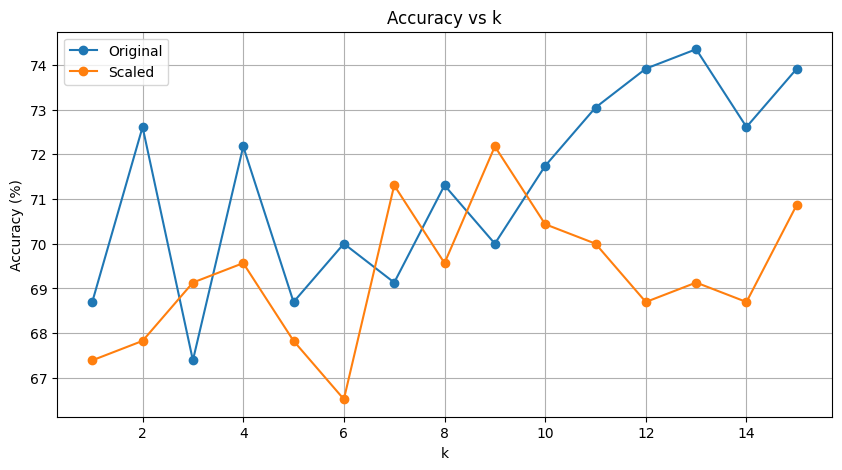

In [31]:
# 2.1 Plot accuracy comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(range(1,16), accuracy_original_list, marker='o', label='Original')
plt.plot(range(1,16), accuracy_scaled_list, marker='o', label='Scaled')
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs k")
plt.legend()
plt.grid(True)
plt.show()


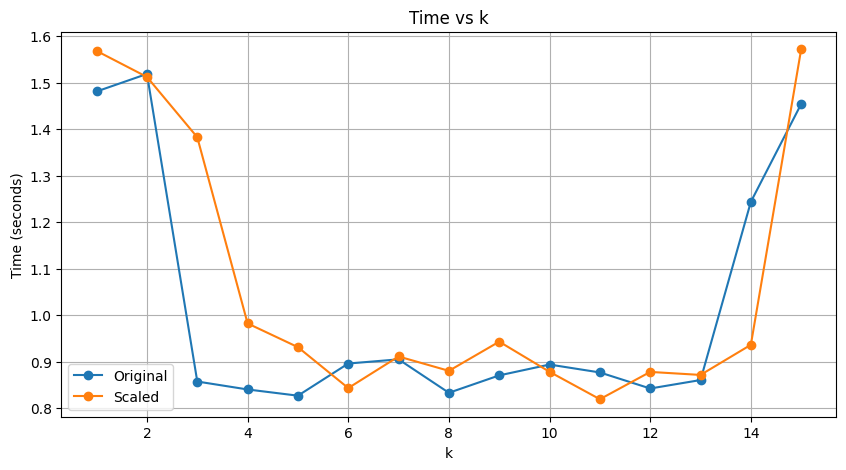

In [32]:
# 2.2 Plot time comparison
plt.figure(figsize=(10,5))
plt.plot(range(1,16), time_original_list, marker='o', label='Original')
plt.plot(range(1,16), time_scaled_list, marker='o', label='Scaled')
plt.xlabel("k")
plt.ylabel("Time (seconds)")
plt.title("Time vs k")
plt.legend()
plt.grid(True)
plt.show()


In [33]:
# 3.1 Find the best k (highest accuracy)
best_k_original = accuracy_original_list.index(max(accuracy_original_list)) + 1
best_k_scaled = accuracy_scaled_list.index(max(accuracy_scaled_list)) + 1

best_k_original, best_k_scaled


(13, 9)